<a href="https://colab.research.google.com/github/trant4-coder/ie7615-dreamers-project/blob/main/IE7615_Project_Dreamers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data preprocessing & EDA


In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=26b7d1bdeeb6d01d78acfd51adb03850f65649bcfc4b806afea103d50f678f20
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from xgboost import XGBClassifier
import joblib
from sklearn.neural_network import MLPClassifier
import shap
import matplotlib.pyplot as plt
import json
from lime import lime_tabular
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive.mount('/content/drive')
# Path to your dataset in Drive
file_path = '/content/drive/MyDrive/IE7615/IE7615 - Project/extended_stress_detection_data.csv'
# Load dataset
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  3000 non-null   float64
 1   Gender               3000 non-null   object 
 2   Occupation           3000 non-null   object 
 3   Marital_Status       3000 non-null   object 
 4   Sleep_Duration       3000 non-null   float64
 5   Sleep_Quality        3000 non-null   float64
 6   Wake_Up_Time         3000 non-null   object 
 7   Bed_Time             3000 non-null   object 
 8   Physical_Activity    3000 non-null   float64
 9   Screen_Time          3000 non-null   float64
 10  Caffeine_Intake      3000 non-null   int64  
 11  Alcohol_Intake       3000 non-null   int64  
 12  Smoking_Habit        3000 non-null   object 
 13  Work_Hours           3000 non-null   float64
 14  Travel_Time          3000 non-null   float64
 15  Social_Interactions  3000 non-null   f

In [ ]:
df["Stress_Detection"]

,Stress_Detection
0,Low
1,Medium
2,High
3,Low
4,Low
...,...
2995,Low
2996,Medium
2997,Medium
2998,High


In [ ]:
# Encode target
target_col = "Stress_Detection"
le = LabelEncoder()
df["Stress_Class"] = le.fit_transform(df[target_col])

# Get numeric & categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove("Stress_Class")

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols.remove(target_col)

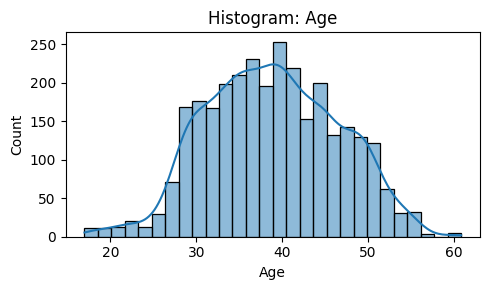

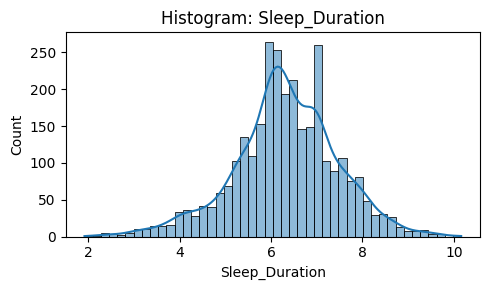

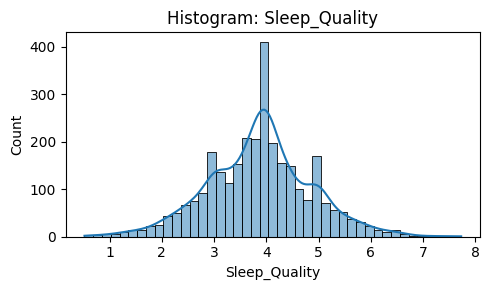

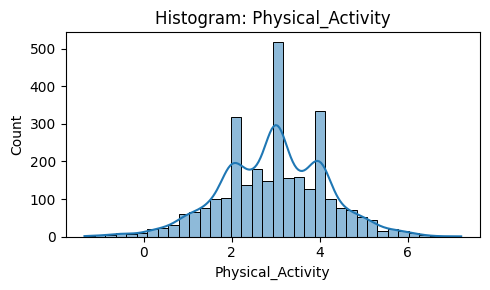

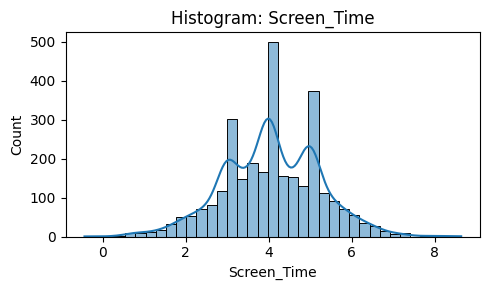

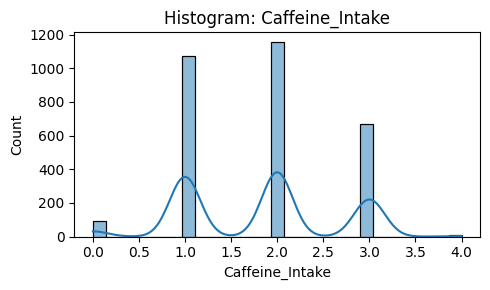

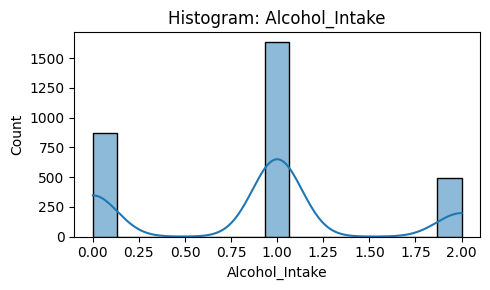

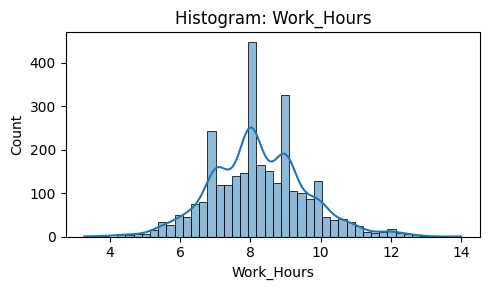

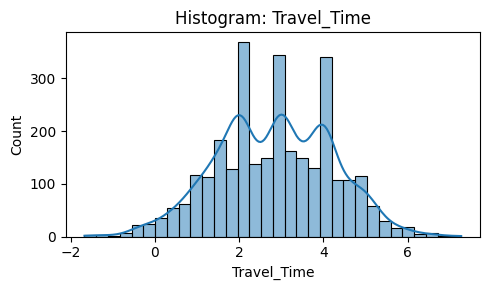

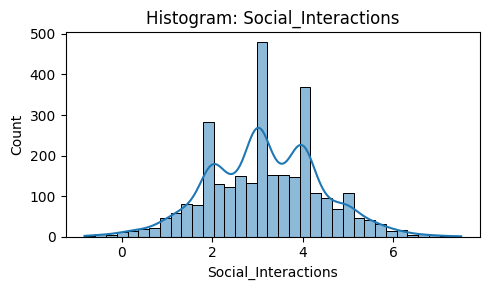

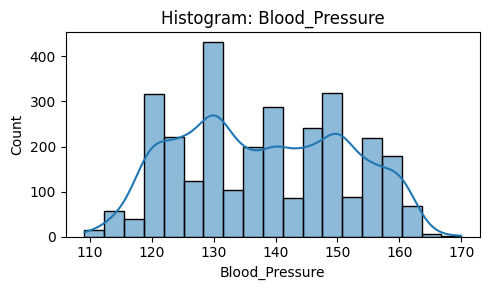

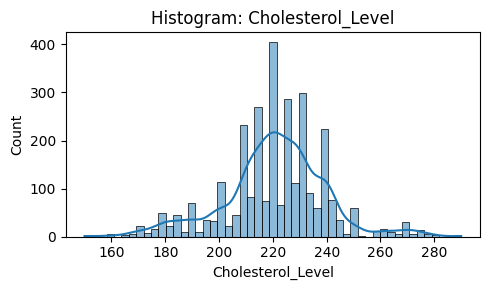

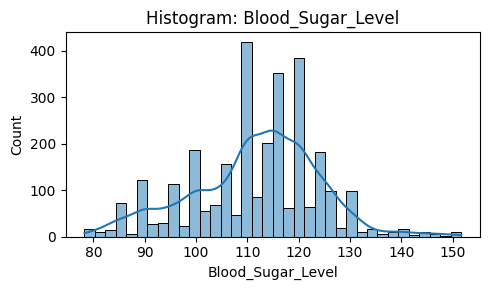

In [ ]:
# 1. Simple histograms for numeric features
for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram: {col}")
    plt.tight_layout()
    plt.show()

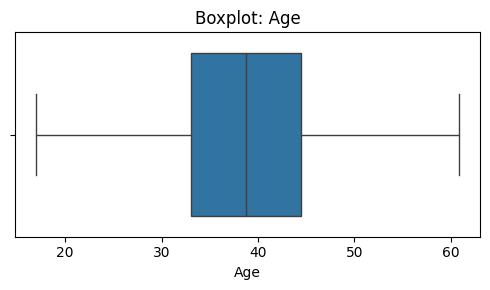

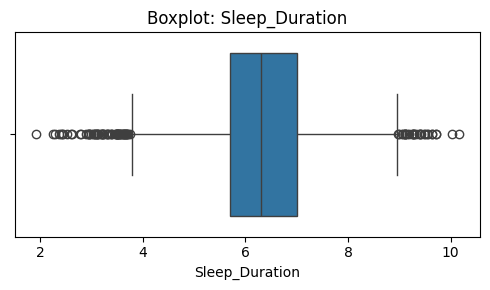

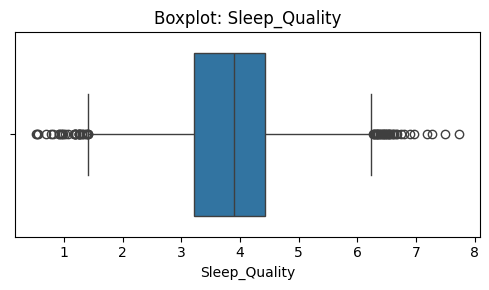

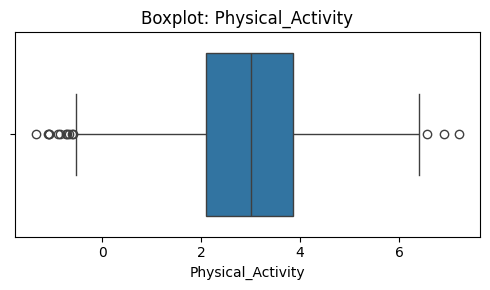

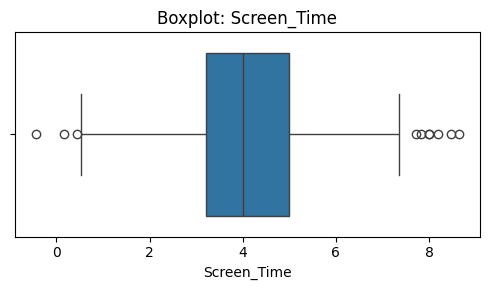

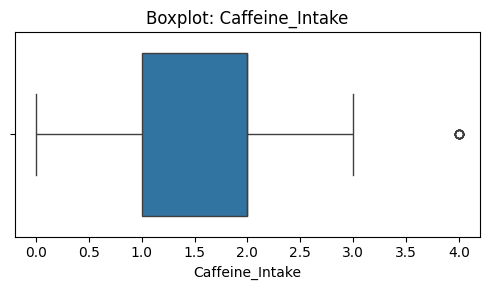

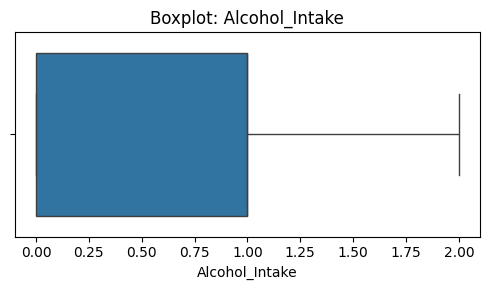

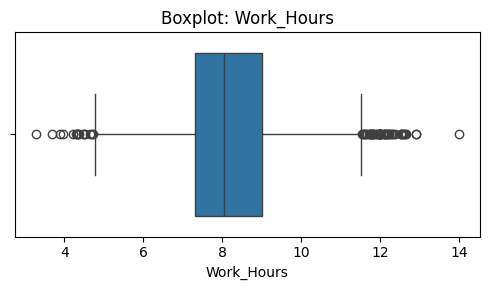

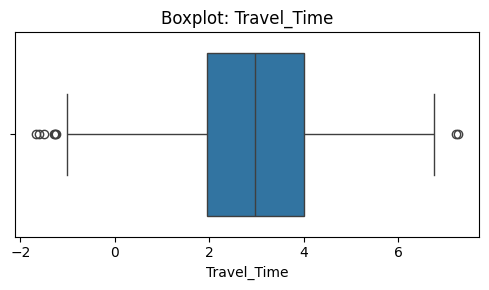

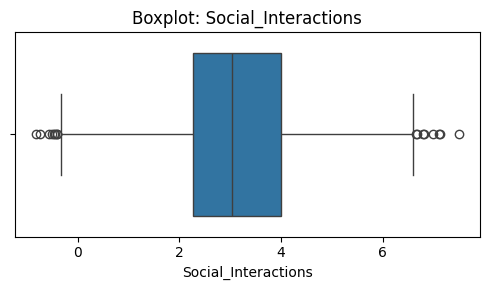

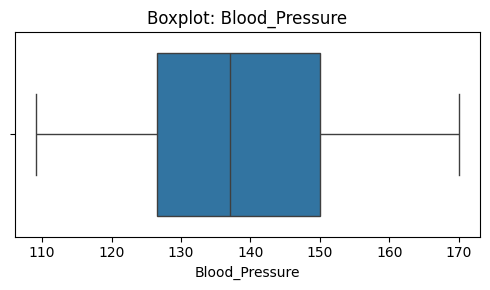

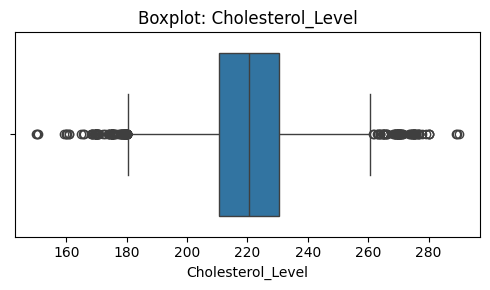

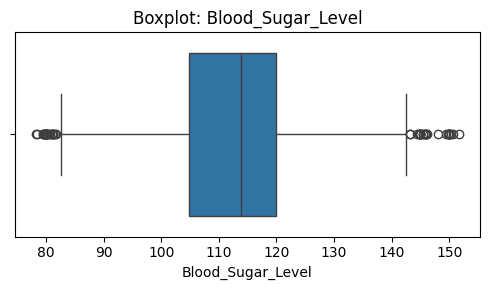

In [ ]:
# 2. Simple boxplots to inspect outliers
for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

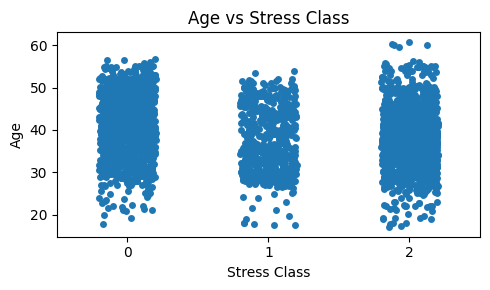

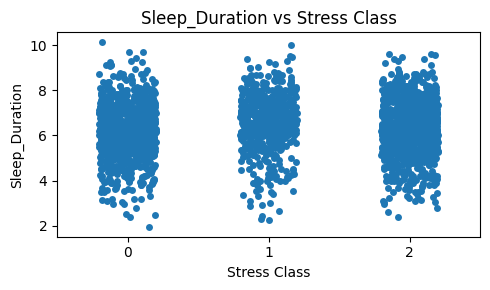

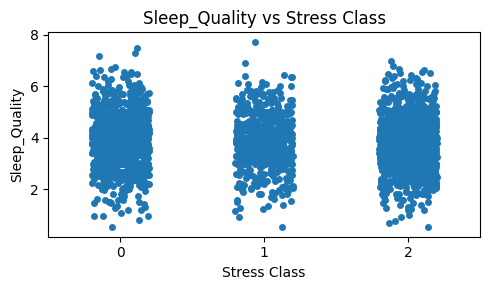

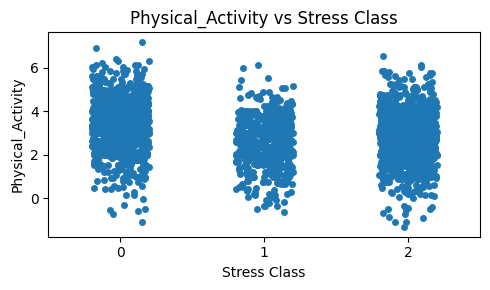

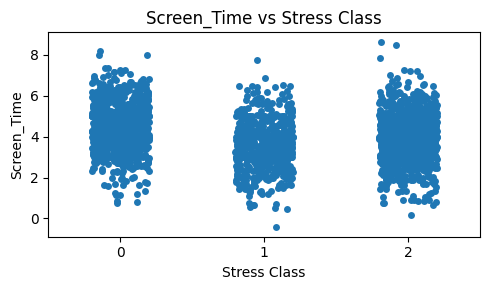

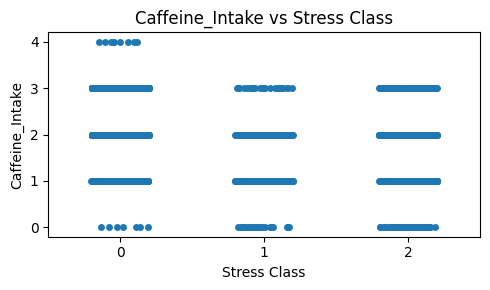

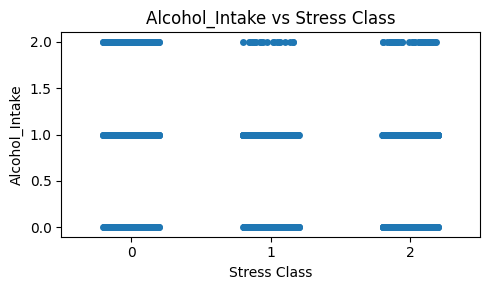

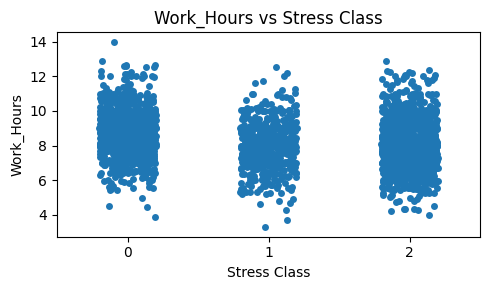

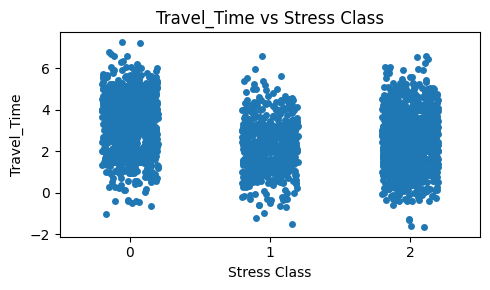

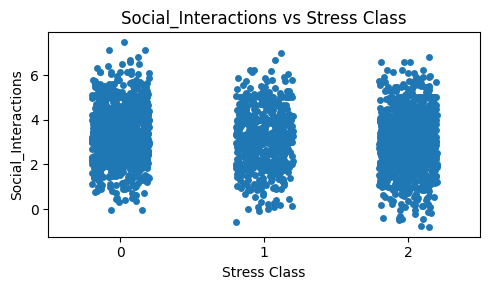

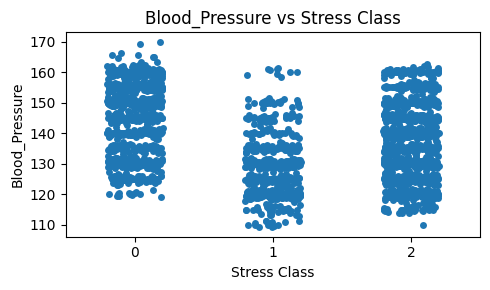

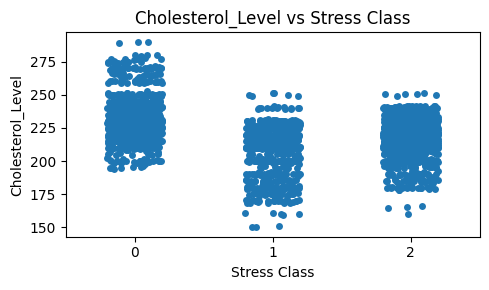

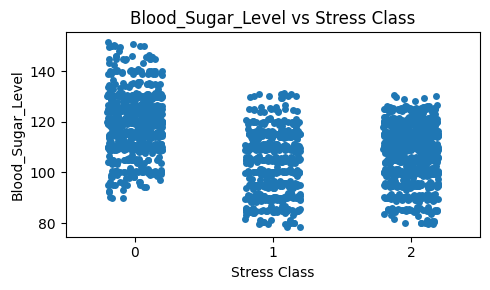

In [ ]:
# 3. Feature vs Stress Class (strip plot)
for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.stripplot(x=df["Stress_Class"], y=df[col], jitter=0.2)
    plt.title(f"{col} vs Stress Class")
    plt.xlabel("Stress Class")
    plt.tight_layout()
    plt.show()

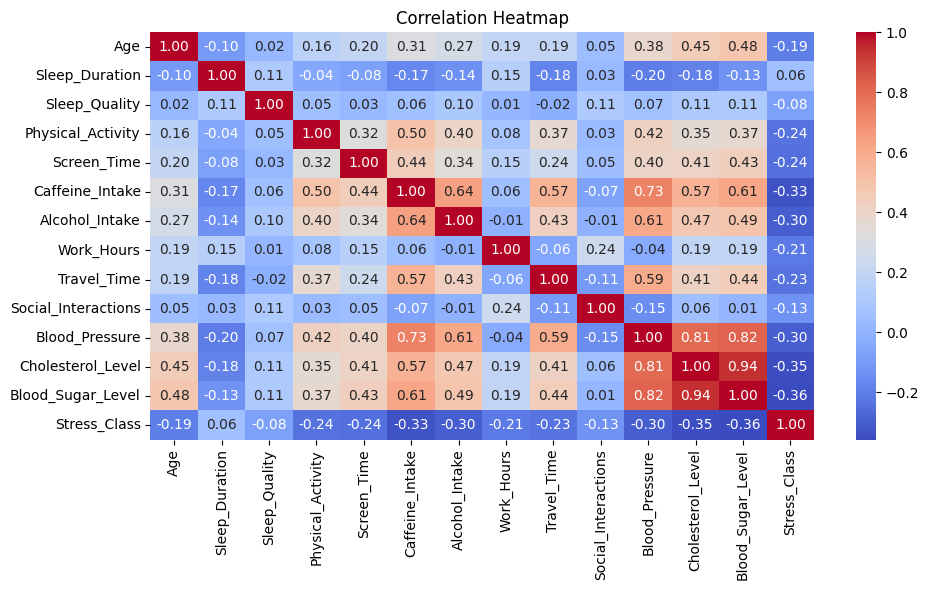

In [ ]:
# 4. Correlation heatmap (simple)
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols + ["Stress_Class"]].corr(),
            cmap="coolwarm", annot=True, fmt=".2f",  )
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Train models with entire dataset

In [ ]:
# One-hot encode categorical features
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove(target_col)   # exclude target

df2 = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Build final X, y
X = df2.drop(columns=["Stress_Detection", "Stress_Class"])
y = df2["Stress_Class"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Scale numeric features
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [ ]:
# MLP Classifier
mlp = MLPClassifier(hidden_layer_sizes=(186,64), activation='tanh',
                        solver='adam', alpha=0.0007, batch_size=32, max_iter=500, random_state=42)

mlp.fit(X_train, y_train)
mlp_train_acc = mlp.score(X_train, y_train)
mlp_test_acc = mlp.score(X_test, y_test)

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_train_acc = lr.score(X_train, y_train)
lr_test_acc = lr.score(X_test, y_test)

In [ ]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=None, random_state=42)
dt.fit(X_train, y_train)
dt_train_acc = dt.score(X_train, y_train)
dt_test_acc = dt.score(X_test, y_test)

In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200,max_depth=None,random_state=42)
rf.fit(X_train, y_train)
rf_train_acc = rf.score(X_train, y_train)
rf_test_acc = rf.score(X_test, y_test)

In [ ]:
# Clean feature names for XGBoost
X_train.columns = X_train.columns.astype(str).str.replace('[', '(', regex=False)
X_train.columns = X_train.columns.astype(str).str.replace(']', ')', regex=False)
X_train.columns = X_train.columns.astype(str).str.replace('<', '_lt_', regex=False)
X_train.columns = X_train.columns.astype(str).str.replace('>', '_gt_', regex=False)

X_test.columns = X_test.columns.astype(str).str.replace('[', '(', regex=False)
X_test.columns = X_test.columns.astype(str).str.replace(']', ')', regex=False)
X_test.columns = X_test.columns.astype(str).str.replace('<', '_lt_', regex=False)
X_test.columns = X_test.columns.astype(str).str.replace('>', '_gt_', regex=False)

# Train XGBoost
xgb = XGBClassifier(objective="multi:softmax", num_class=3, eval_metric='mlogloss', learning_rate=0.05,
    max_depth=6, n_estimators=300, subsample=0.9, random_state=42)

xgb.fit(X_train, y_train)
xgb_train_acc = xgb.score(X_train, y_train)
xgb_test_acc = xgb.score(X_test, y_test)

In [ ]:
# Compare models' performance
results = {
    "Model": ["MLP", "Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Train Accuracy": [mlp_train_acc, lr_train_acc, dt_train_acc, rf_train_acc, xgb_train_acc],
    "Test Accuracy": [mlp_test_acc, lr_test_acc, dt_test_acc, rf_test_acc, xgb_test_acc]}
results_df = pd.DataFrame(results)

# Format to 3 decimal places for readability
results_df["Train Accuracy"] = results_df["Train Accuracy"].round(3)
results_df["Test Accuracy"] = results_df["Test Accuracy"].round(3)

results_df

,Model,Train Accuracy,Test Accuracy
0,MLP,1.000,0.969
1,Logistic Regression,0.810,0.783
2,Decision Tree,1.000,0.945
3,Random Forest,1.000,0.932
4,XGBoost,0.996,0.916


# Explanability Comparison

## 1. Global Interpretation

### Decision Tree

Text(0.5, 0, 'Feature Importance (Gini Gain)')

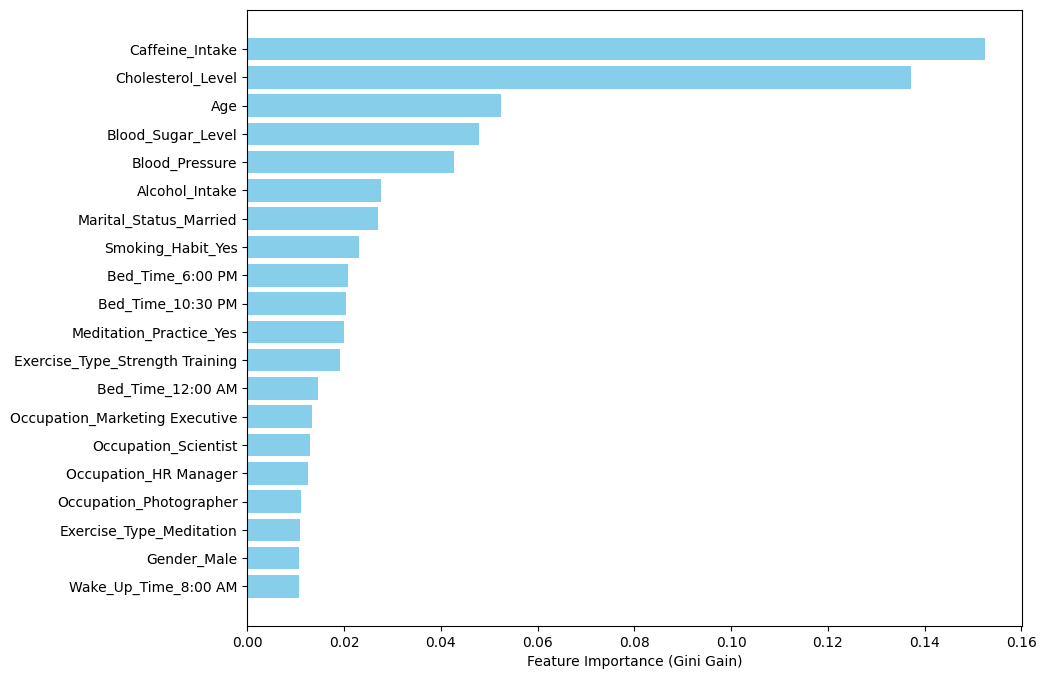

In [ ]:
# Extract features names
feature_names = X.columns.tolist()

# Extract importances from the model
importances = dt.feature_importances_

# Sort by importance (descending)
indices = np.argsort(importances)[::-1]

# Select top 20
top_n = 20
top_indices = indices[:top_n]

# Prepare plot
plt.figure(figsize=(10, 8))
plt.barh(y=np.arange(top_n), width=importances[top_indices][::-1], color="skyblue")
plt.yticks(np.arange(top_n),
    [feature_names[i] for i in top_indices[::-1]],  # highest at bottom for readability
    fontsize=10)
plt.xlabel("Feature Importance (Gini Gain)")

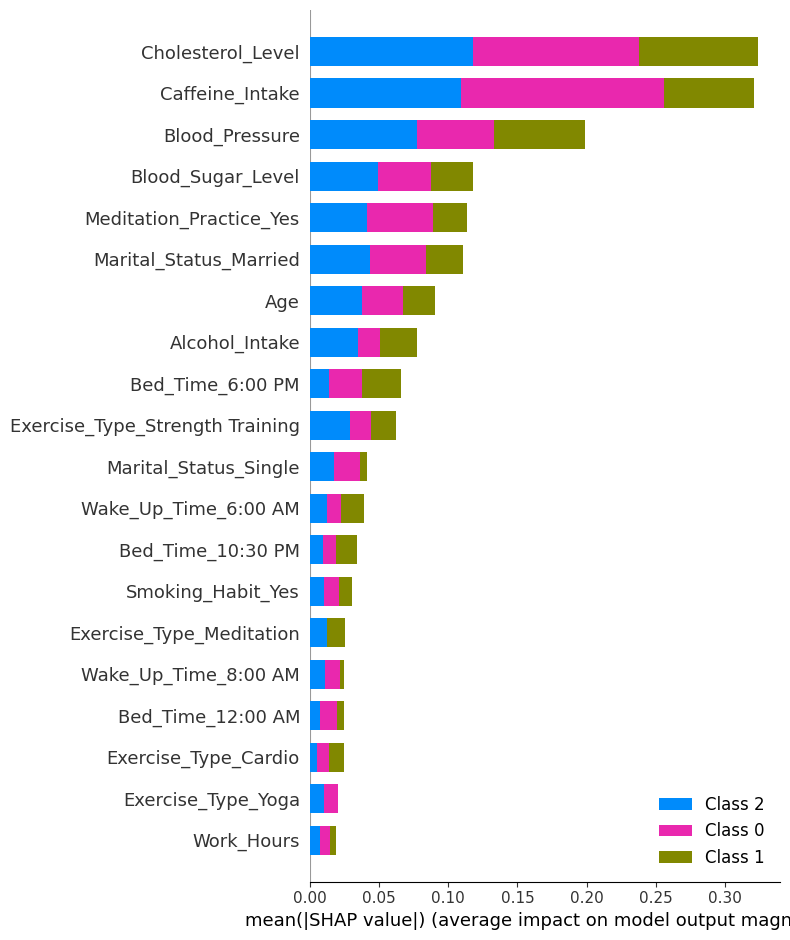

In [ ]:
# TreeSHAP for Decision Tree
# Create TreeExplainer (optimized for tree models)
explainer_dt = shap.TreeExplainer(dt)

# Compute SHAP values for the decision tree
shap_values_dt = explainer_dt.shap_values(X_test_shap)

# Global feature importance bar plot
shap.summary_plot(
    shap_values_dt,
    X_test_shap,
    feature_names=feature_names,
    plot_type="bar")

### MLP

In [ ]:
# SHAP requires the exact training matrix used by the MLP
X_train_shap = X_train.copy()
X_test_shap  = X_test.copy()

# SHAP input matrix must be float dtype
X_train_shap = X_train_shap.astype(float)
X_test_shap  = X_test_shap.astype(float)

PermutationExplainer explainer: 751it [04:20,  2.80it/s]
/tmp/ipython-input-3800666647.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


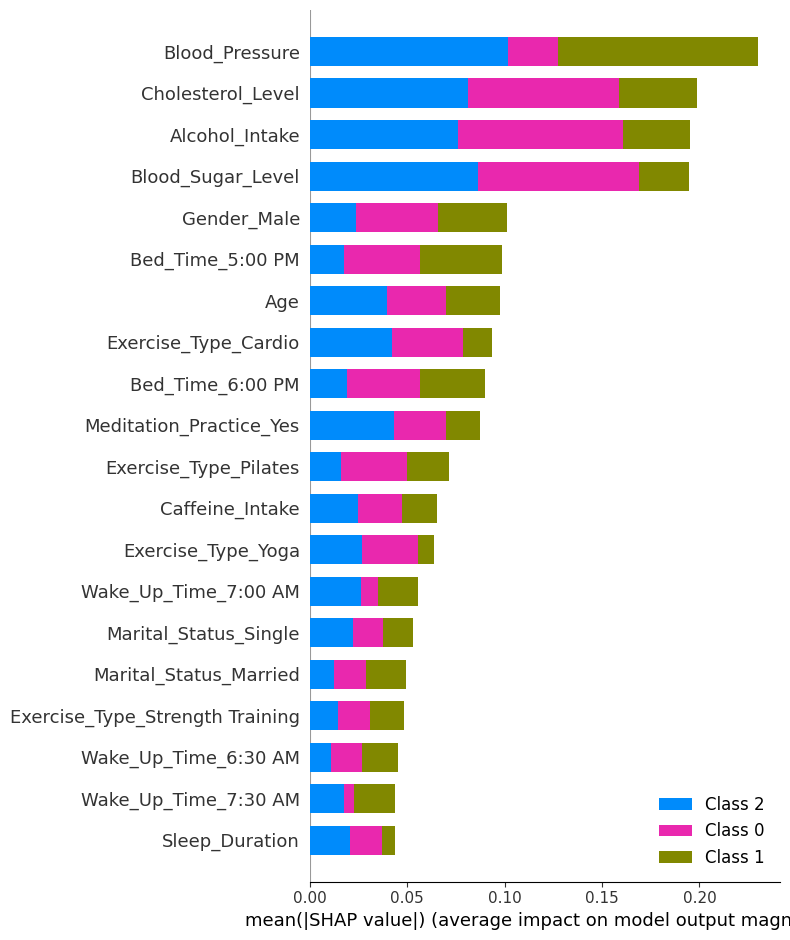

In [ ]:
# Create SHAP explainer for MLP
explainer_mlp = shap.Explainer(mlp.predict_proba, X_train_shap)

# Compute SHAP values
shap_values_mlp = explainer_mlp(X_test_shap)

# Global feature importance (bar plot)
shap.summary_plot(
    shap_values_mlp,
    X_test_shap,
    feature_names=feature_names,
    plot_type="bar")

/tmp/ipython-input-3856711651.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_mlp[:, :, 0], X_test_shap, feature_names=feature_names, show=False)


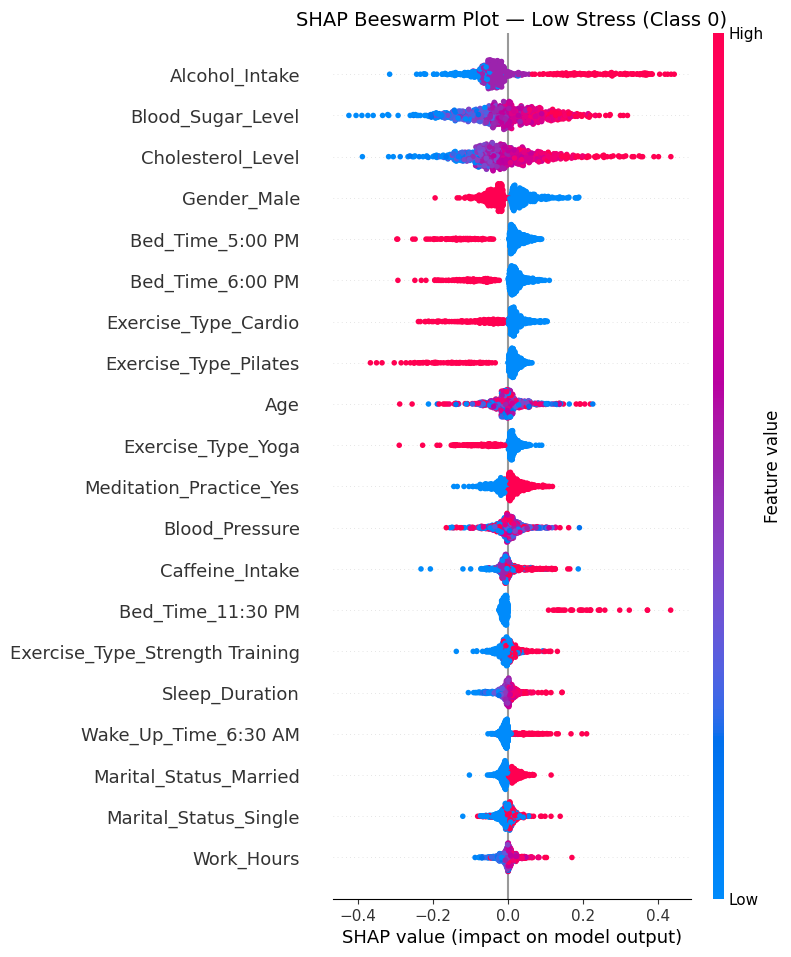

/tmp/ipython-input-3856711651.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_mlp[:, :, 1], X_test_shap, feature_names=feature_names,show=False)


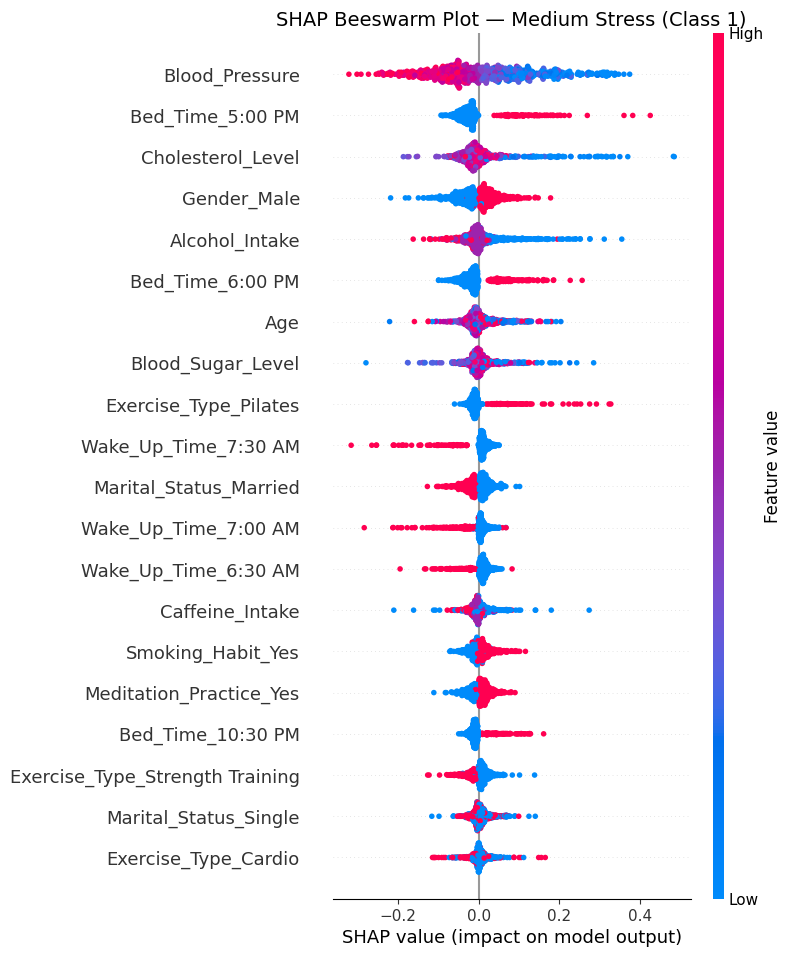

/tmp/ipython-input-3856711651.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_mlp[:, :, 2], X_test_shap, feature_names=feature_names, show=False)


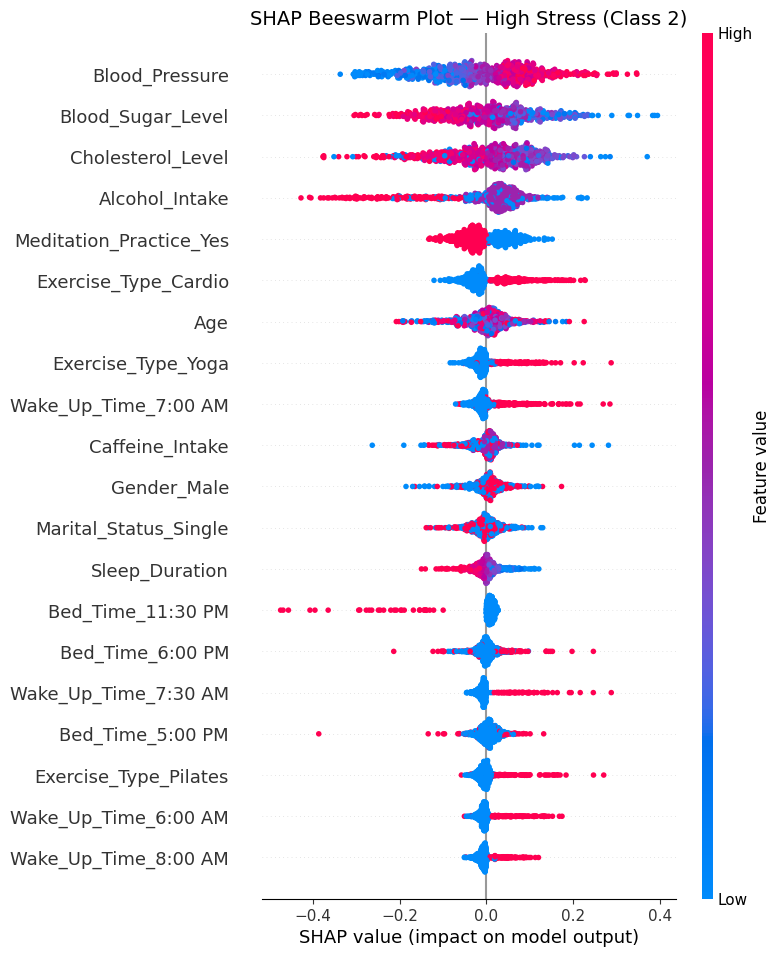

In [ ]:
# LOW STRESS (class 0)
shap.summary_plot(shap_values_mlp[:, :, 0], X_test_shap, feature_names=feature_names, show=False)
plt.title("SHAP Beeswarm Plot — Low Stress (Class 0)", fontsize=14)
plt.show()

# MEDIUM STRESS (class 1)
shap.summary_plot(shap_values_mlp[:, :, 1], X_test_shap, feature_names=feature_names,show=False)
plt.title("SHAP Beeswarm Plot — Medium Stress (Class 1)", fontsize=14)
plt.show()

# HIGH STRESS (class 2)
shap.summary_plot(shap_values_mlp[:, :, 2], X_test_shap, feature_names=feature_names, show=False)
plt.title("SHAP Beeswarm Plot — High Stress (Class 2)", fontsize=14)
plt.show()

## 2. Local Explanation

### Decision rules for Decision Tree

In [ ]:
# Decision Tree local explanation
sample = X_test.iloc[0:1]
node_indicator = dt.decision_path(sample)
leave_id = dt.apply(sample)

feature = dt.tree_.feature
threshold = dt.tree_.threshold

print("Decision path:")
for node_id in node_indicator.indices:
    if node_id == leave_id:
        continue
    if sample.iloc[0, feature[node_id]] <= threshold[node_id]:
        threshold_sign = "<="
    else:
        threshold_sign = ">"
    print(f"{feature_names[feature[node_id]]} {threshold_sign} {threshold[node_id]:.2f}")

Decision path:
Caffeine_Intake <= 0.84
Cholesterol_Level > -1.55
Cholesterol_Level <= 1.16
Blood_Pressure <= -0.06
Bed_Time_6:00 PM <= 0.50
Cholesterol_Level > -0.36
Marital_Status_Married <= 0.50
Wake_Up_Time_6:00 AM <= 0.50
Cholesterol_Level > 0.19
Smoking_Habit_Yes <= 0.50
Occupation_Scientist <= 0.50
Occupation_Taxi Driver <= 0.50


### Explanation using LIME for MLP

In [ ]:
# Scale numeric features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Convert to float numpy arrays
X_train_float = X_train_scaled.astype(float)
X_test_float = X_test_scaled.astype(float)

In [ ]:
# User and true label
i = 0
true_label = y_test.iloc[i]
class_map = {0: "Low", 1: "Medium", 2: "High"}
true_label_name = class_map[true_label]

In [ ]:
# Predict class for LIME using MLP (neural net → MUST USE SCALED DATA)
probs = mlp.predict(X_test_scaled.iloc[i:i+1])[0]
mlp_pred_class = np.argmax(probs)

# LIME explainer
lime_explainer_mlp = lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=X_train_scaled.columns.tolist(),
    class_names=["Low", "Medium", "High"],
    mode="classification")

# Explain one instance
exp_mlp = lime_explainer_mlp.explain_instance(
    data_row=X_test_scaled.iloc[i].values,
    predict_fn=mlp.predict_proba,
    num_features=10,
    labels=[mlp_pred_class])

exp_mlp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


## Results Analysis


In [ ]:
# ================================================================
# PREPARE SCALED DATA FOR LIME & SHAP
# ================================================================
#X_train_scaled = X_train.copy()
#X_test_scaled  = X_test.copy()



# ================================================================
# 1. SUBGROUP PERFORMANCE FUNCTION
# ================================================================
def subgroup_performance(model, X_test, y_test, df_original, group_col):
    df_sub = df_original.loc[X_test.index]
    groups = df_sub[group_col].unique()

    rows = []

    for g in groups:
        mask = (df_sub[group_col] == g)
        if mask.sum() < 10:
            continue

        y_true = y_test[mask]
        y_pred = model.predict(X_test[mask])

        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, average="macro")

        rows.append([g, mask.sum(), acc, f1])

    return pd.DataFrame(rows, columns=["Group", "Count", "Accuracy", "Macro-F1"])


# ================================================================
# 2. FAIRNESS METRICS (SPD, DI, EOD, Accuracy Gap)
# ================================================================
def statistical_parity_difference(y_pred, sensitive):
    pA = y_pred[sensitive == 0].mean()
    pB = y_pred[sensitive == 1].mean()
    return pA - pB

def disparate_impact(y_pred, sensitive):
    pA = y_pred[sensitive == 0].mean()
    pB = y_pred[sensitive == 1].mean()
    return pA / (pB + 1e-12)

def equal_opportunity_diff(y_true, y_pred, sensitive):
    tprA = recall_score(y_true[sensitive == 0], y_pred[sensitive == 0], average="macro")
    tprB = recall_score(y_true[sensitive == 1], y_pred[sensitive == 1], average="macro")
    return tprA - tprB

def accuracy_gap(y_true, y_pred, sensitive):
    accA = accuracy_score(y_true[sensitive == 0], y_pred[sensitive == 0])
    accB = accuracy_score(y_true[sensitive == 1], y_pred[sensitive == 1])
    return accA - accB


# ================================================================
# 3. ROBUSTNESS TEST (Noise Sensitivity)
# ================================================================
def robustness_test(model, X_test, y_test, noise_std=0.05):
    X_noisy = X_test + np.random.normal(0, noise_std, X_test.shape)
    acc_clean = model.score(X_test, y_test)
    acc_noisy = model.score(X_noisy, y_test)
    return acc_clean, acc_noisy, acc_clean - acc_noisy


# ================================================================
# 4. SHAP–LIME AGREEMENT
# ================================================================
def shap_lime_agreement(shap_vals, lime_exp, feature_names, top_k=10):

    # SHAP top features
    shap_importance = np.mean(np.abs(shap_vals.values), axis=0)
    shap_rank = np.argsort(shap_importance)[::-1][:top_k]
    shap_features = [feature_names[i] for i in shap_rank]

    # LIME top features
    lime_features = [f for f, _ in lime_exp.as_list(label=lime_exp.available_labels()[0])][:top_k]

    # Agreement
    overlap = set(shap_features) & set(lime_features)
    score = len(overlap) / top_k

    return shap_features, lime_features, overlap, score


# ================================================================
# 5. FAITHFULNESS TEST
# ================================================================
def feature_removal_test(model, X_test, y_test, feature):
    X_mod = X_test.copy()
    X_mod[feature] = 0
    acc_orig = model.score(X_test, y_test)
    acc_new  = model.score(X_mod, y_test)
    return acc_orig, acc_new, acc_orig - acc_new


# ================================================================
# RUN ALL ANALYSES
# ================================================================

# -----------------------------------
# A. SUBGROUP PERFORMANCE TABLES
# -----------------------------------
print("=== SUBGROUP PERFORMANCE: GENDER ===")
gender_perf = subgroup_performance(mlp, X_test, y_test, df, "Gender")
print(gender_perf.to_string(index=False))

print("\n=== SUBGROUP PERFORMANCE: AGE CATEGORY ===")
age_perf = subgroup_performance(mlp, X_test, y_test, df, "Age")
print(age_perf.to_string(index=False))

print("\n=== SUBGROUP PERFORMANCE: marital status ===")
loc_perf = subgroup_performance(mlp, X_test, y_test, df, "Marital_Status")
print(loc_perf.to_string(index=False))


# -----------------------------------
# B. FAIRNESS METRICS
# -----------------------------------
gender_map = df["Gender"].astype("category").cat.codes.loc[y_test.index]
y_pred_mlp = mlp.predict(X_test)

fairness_gender = {
    "SPD": statistical_parity_difference(y_pred_mlp, gender_map),
    "DI":  disparate_impact(y_pred_mlp, gender_map),
    "EOD": equal_opportunity_diff(y_test, y_pred_mlp, gender_map),
    "Accuracy Gap": accuracy_gap(y_test, y_pred_mlp, gender_map)
}

print("\n=== FAIRNESS METRICS (GENDER) ===")
print(fairness_gender)


# -----------------------------------
# C. ROBUSTNESS TEST
# -----------------------------------
acc_clean, acc_noisy, drop = robustness_test(mlp, X_test, y_test)

print("\n=== ROBUSTNESS TEST ===")
print(f"Accuracy (clean): {acc_clean:.4f}")
print(f"Accuracy (noisy): {acc_noisy:.4f}")
print(f"Accuracy Drop:    {drop:.44f}")


# -----------------------------------
# D. SHAP → already computed earlier
# LIME → recompute for one sample
# -----------------------------------
i = 0
mlp_pred_class = mlp.predict(X_test_scaled.iloc[i:i+1])[0]

lime_explainer_mlp = lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=X_train_scaled.columns.tolist(),
    class_names=["Low", "Medium", "High"],
    mode="classification",
)

exp_mlp = lime_explainer_mlp.explain_instance(
    data_row=X_test_scaled.iloc[i].values,
    predict_fn=mlp.predict_proba,
    num_features=10,
    labels=[mlp_pred_class]
)

# SHAP–LIME Agreement
shap_feat, lime_feat, overlap, agree = shap_lime_agreement(
    shap_values_mlp[:, :, 0],
    exp_mlp,
    feature_names
)

print("\n=== SHAP–LIME AGREEMENT ===")
print("SHAP Top Features:", shap_feat)
print("LIME Top Features:", lime_feat)
print("Overlap:", overlap)
print(f"Agreement Score = {agree:.2f}")


# -----------------------------------
# E. FAITHFULNESS TEST
# -----------------------------------
top_feature = shap_feat[0]

acc_orig, acc_removed, drop = feature_removal_test(mlp, X_test, y_test, top_feature)

print("\n=== FAITHFULNESS TEST ===")
print("Feature removed:", top_feature)
print(f"Original Accuracy: {acc_orig:.4f}")
print(f"After Removing:    {acc_removed:.4f}")
print(f"Drop:              {drop:.4f}")


=== SUBGROUP PERFORMANCE: GENDER ===
 Group  Count  Accuracy  Macro-F1
  Male    373  0.973190  0.970711
Female    377  0.965517  0.962389

=== SUBGROUP PERFORMANCE: AGE CATEGORY ===
 Group  Count  Accuracy  Macro-F1
  38.0     13  0.923077  0.911111
  50.0     15  0.933333  0.934837
  36.0     11  0.909091  0.822222
  35.0     11  1.000000  1.000000
  41.0     15  1.000000  1.000000
  40.0     11  1.000000  1.000000
  29.0     10  1.000000  1.000000

=== SUBGROUP PERFORMANCE: marital status ===
   Group  Count  Accuracy  Macro-F1
Divorced     66  1.000000  1.000000
 Married    340  0.970588  0.958994
  Single    344  0.962209  0.958896

=== FAIRNESS METRICS (GENDER) ===
{'SPD': np.float64(0.20492671791553185), 'DI': np.float64(1.219019099662002), 'EOD': -0.012402426165704417, 'Accuracy Gap': -0.007673107146158764}

=== ROBUSTNESS TEST ===
Accuracy (clean): 0.9693
Accuracy (noisy): 0.9240
Accuracy Drop:    0.04533333333333333658998753890045918524265289


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(



=== SHAP–LIME AGREEMENT ===
SHAP Top Features: ['Alcohol_Intake', 'Blood_Sugar_Level', 'Cholesterol_Level', 'Gender_Male', 'Bed_Time_5:00 PM', 'Bed_Time_6:00 PM', 'Exercise_Type_Cardio', 'Exercise_Type_Pilates', 'Age', 'Exercise_Type_Yoga']
LIME Top Features: ['Occupation_IT Manager <= 0.00', 'Occupation_Sales Executive <= 0.00', 'Bed_Time_12:00 AM <= 0.00', 'Occupation_Dentist <= 0.00', 'Occupation_Content Strategist <= 0.00', 'Occupation_Police Officer <= 0.00', 'Occupation_Banker <= 0.00', 'Occupation_Customer Support <= 0.00', 'Occupation_Physician <= 0.00', 'Occupation_Nutritionist <= 0.00']
Overlap: set()
Agreement Score = 0.00

=== FAITHFULNESS TEST ===
Feature removed: Alcohol_Intake
Original Accuracy: 0.9693
After Removing:    0.8987
Drop:              0.0707
